# Phase-2 L1 Trigger: ML-based PUPPI algorithm

## Target
For the Phase-2 L1 Trigger Upgrade, the CMS L1 Trigger will perform Particle Flow (PF) and PUPPI reconstruction for the first time, withing a processing latency around 1 μs. 

The current PUPPI implementation reduces the number of PF candidates by a factor of about 10.
* For charged, it evaluates if the particle is assigned to the primary vertex or not and assigns 0 or 1;
* for neutrals, it assigns a weight computed between [0,1] to correct the neutral candidate $p_T$.

The first approach to develop a ML-based PUPPI algorithm is the attempt of regressing the hard-scatter contribution for neutral PF candidates by exploiting as a target for the regression a gen-based energy ratio. 


## Samples

We exploit FastPUPPI ntuples from TTbar inclusive samples (at different PU scenarios: PU0, PU140, PU200) obtained from the latest inputs (after AR2025: latest and greatest PF).

Ntuples available at:
* `/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/`

with hadded files:
* `perfNano_PU0.root`
* `perfNano_PU140.root`
* `perfNano_PU200.root`

All single ntuples before hadd also available:
* `/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/TT_PU0/FP/151Xv0/`
* `/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/TT_PU150/FP/151Xv0/`
* `/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/TT_PU200/FP/151Xv0/`

## Imports

In [1]:
import os
import glob
import math
import json
import h5py
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score

from tqdm import tqdm
import mplhep as hep

## Configuration: prepare data from root file

In [2]:
CONFIG = {
    "input_path": "fpNtuples/",
    "pattern": "perfNano*.root",
    "tree_name": "Events",

    "output_dir": "PUPPILML_NeutralWeight_Barrel/",
    "dataset_file": "PUPPILML_NeutralWeight_Barrel/neutral_weight_dataset_dR0p2_nPF128_logpt_dEta_dPhi_charge_isSeed_standInputs-twoFiles.h5",
    "model_file": "PUPPILML_NeutralWeight_Barrel/best_model.pt",

    # Dataset building
    "max_files": 2,         # -1 = all files
    "n_pf_per_sample": 128,
    "cone_dr": 0.2,
    "eps": 1e-6,

    # Masks: barrel selection
    "only_barrel_neutrals": True,
    "barrel_eta_max": 1.5,

    # Branches
    "branches": {
        "pt": "L1PuppiCands_pt",
        "eta": "L1PuppiCands_eta",
        "phi": "L1PuppiCands_phi",
        #"caloEta": "L1PuppiCands_caloEta",
        #"caloPhi": "L1PuppiCands_caloPhi",
        "charge": "L1PuppiCands_charge",

        "genPtSum": "L1PuppiCands_genPtSum0p2",
        "recoPtSum": "L1PuppiCands_recoDen_seedPlusAll0p2",
        "isGenMatched": "L1PuppiCands_isGenMatched",
        "puppiWeight": "L1PuppiCands_puppiWeight",
    },

    # model features per PF candidate
    "model_features": ["logpt", "dEta", "dPhi", "dR", "charge", "is_seed"],

    # training
    "seed": 42, # Seeding controls: dataset splitting (train/val/test), weight initialization, shuffling
    "batch_size": 512,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "num_workers": 0,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 1e-4,

    # split
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,
}

In [3]:
files = sorted(glob.glob(os.path.join(CONFIG["input_path"], CONFIG["pattern"])))
if CONFIG["max_files"] > 0:
    files = files[:CONFIG["max_files"]]

print("Found files:", len(files))
print("First file:", files[0] if files else "None")

if files:
    tree = uproot.open(f"{files[0]}:{CONFIG['tree_name']}")
    b = CONFIG["branches"]

    arrs = tree.arrays([
        b["pt"],
        b["genPtSum"],
        b["recoPtSum"],
        b["isGenMatched"],
        b["puppiWeight"],
        b["eta"],
        b["phi"],
        b["charge"],
    ], library="ak")

    iev = 0

    pt = np.asarray(arrs[b["pt"]][iev], dtype=np.float32)
    eta = np.asarray(arrs[b["eta"]][iev], dtype=np.float32)
    phi = np.asarray(arrs[b["phi"]][iev], dtype=np.float32)
    charge = np.asarray(arrs[b["charge"]][iev], dtype=np.float32)

    gen_pt_sum = np.asarray(arrs[b["genPtSum"]][iev], dtype=np.float32)
    reco_pt_sum = np.asarray(arrs[b["recoPtSum"]][iev], dtype=np.float32)
    is_gen_matched = np.asarray(arrs[b["isGenMatched"]][iev], dtype=np.int32)
    puppi_weight = np.asarray(arrs[b["puppiWeight"]][iev], dtype=np.float32)

    print("=" * 80)
    print("EVENT CONTENT CHECK")
    print("=" * 80)
    print("Event", iev)
    print("n pt           :", len(pt))
    print("n genPtSum     :", len(gen_pt_sum))
    print("n recoPtSum    :", len(reco_pt_sum))
    print("n isGenMatched :", len(is_gen_matched))
    print("n puppiWeight  :", len(puppi_weight))

    print("\n" + "=" * 80)
    print("ETA/PHI CONTENT USED FOR CONE BUILDING")
    print("=" * 80)
    print("eta unique values (first 20):", np.unique(eta)[:20])
    print("phi unique values (first 20):", np.unique(phi)[:20])

    print("\neta min/max :", eta.min(), eta.max())
    print("phi min/max :", phi.min(), phi.max())

    print("\n# unique eta :", len(np.unique(eta)))
    print("# unique phi :", len(np.unique(phi)))

    print("\n" + "=" * 80)
    print("FIRST 20 CANDIDATES")
    print("=" * 80)
    print(f"{'idx':>4s} {'pt':>8s} {'charge':>8s} {'eta':>10s} {'phi':>10s}")
    for i in range(min(20, len(pt))):
        print(f"{i:4d} {pt[i]:8.3f} {charge[i]:8.1f} {eta[i]:10.4f} {phi[i]:10.4f}")

    print("\n" + "=" * 80)
    print("ETA/PHI-CONE DEBUG AROUND FIRST NEUTRAL SEED")
    print("=" * 80)

    neutral_idx = np.where(charge == 0)[0]
    print("Number of neutral candidates:", len(neutral_idx))

    if len(neutral_idx) > 0:
        seed_idx = neutral_idx[0]
        seed_pt = pt[seed_idx]
        seed_eta = eta[seed_idx]
        seed_phi = phi[seed_idx]

        def delta_phi(phi1, phi2):
            dphi = phi1 - phi2
            return (dphi + np.pi) % (2 * np.pi) - np.pi

        d_eta = eta - seed_eta
        d_phi = delta_phi(phi, seed_phi)
        d_r = np.sqrt(d_eta**2 + d_phi**2)

        print(f"Seed idx        : {seed_idx}")
        print(f"Seed pt         : {seed_pt:.4f}")
        print(f"Seed eta        : {seed_eta:.4f}")
        print(f"Seed phi        : {seed_phi:.4f}")
        print(f"Seed is matched : {is_gen_matched[seed_idx]}")
        print(f"Seed PUPPI w    : {puppi_weight[seed_idx]:.4f}")
        print(f"Seed recoPtSum  : {reco_pt_sum[seed_idx]:.4f}")
        print(f"Seed genPtSum   : {gen_pt_sum[seed_idx]:.4f}")

        print("\nFirst 20 dEta/dPhi/dR w.r.t. eta/phi seed:")
        print(f"{'idx':>4s} {'dEta':>12s} {'dPhi':>12s} {'dR':>12s}")
        for i in range(min(20, len(d_r))):
            print(f"{i:4d} {d_eta[i]:12.6f} {d_phi[i]:12.6f} {d_r[i]:12.6f}")

        in_cone = np.where(d_r < CONFIG["cone_dr"])[0]
        print(f"\nCandidates in eta/phi cone dR < {CONFIG['cone_dr']}: {len(in_cone)}")

        print("Unique dR values (first 20):", np.unique(np.round(d_r, 6))[:20])
        print("dR min/max:", d_r.min(), d_r.max())

        print("\nFirst 20 indices in cone:", in_cone[:20])

        print("\nFirst 20 candidates in cone:")
        print(f"{'idx':>4s} {'pt':>8s} {'charge':>8s} {'dEta':>12s} {'dPhi':>12s} {'dR':>12s}")
        for idx in in_cone[:20]:
            print(
                f"{idx:4d} {pt[idx]:8.3f} {charge[idx]:8.1f} "
                f"{d_eta[idx]:12.6f} {d_phi[idx]:12.6f} {d_r[idx]:12.6f}"
            )

    else:
        print("No neutral candidates found in this event.")

Found files: 2
First file: fpNtuples/perfNano_16695316_110.root
EVENT CONTENT CHECK
Event 0
n pt           : 328
n genPtSum     : 328
n recoPtSum    : 328
n isGenMatched : 328
n puppiWeight  : 328

ETA/PHI CONTENT USED FOR CONE BUILDING
eta unique values (first 20): [-5.0265484 -5.022185  -5.0134583 -5.0090947 -5.0047317 -5.000368
 -4.9916415 -4.9872785 -4.978552  -4.9741883 -4.620759  -4.4593163
 -4.4505897 -4.4331365 -4.2586036 -4.2280602 -4.1277037 -4.0971603
 -4.0884337 -2.7183502]
phi unique values (first 20): [-3.119776  -3.080506  -3.054326  -3.0281463 -2.984513  -2.9801497
 -2.9757864 -2.9234264 -2.8841565 -2.8710666 -2.84925   -2.83616
 -2.8317966 -2.8143435 -2.8056169 -2.79689   -2.7052603 -2.700897
 -2.6921704 -2.674717 ]

eta min/max : -5.0265484 5.022185
phi min/max : -3.119776 3.132866

# unique eta : 279
# unique phi : 279

FIRST 20 CANDIDATES
 idx       pt   charge        eta        phi
   0    5.250      0.0    -1.3177    -0.0349
   1    2.750     -1.0    -1.3526    -0

## Utilities

In [4]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi


def dr2(eta1, phi1, eta2, phi2):
    deta = eta1 - eta2
    dphi = delta_phi(phi1, phi2)
    return deta * deta + dphi * dphi


def safe_clip_weight(gen_pt_sum, reco_pt_sum, eps=1e-6):
    return np.clip(gen_pt_sum / np.maximum(reco_pt_sum, eps), 0.0, 1.0)

## Build dataset from ROOT to HDF5

In [5]:
def build_neutral_weight_dataset(config):
    """
    Build a per-neutral-reco-candidate dataset using eta/phi geometry.

    Each sample corresponds to one neutral reco candidate (charge == 0),
    optionally restricted to barrel seeds.

    Geometry is defined with:
      - seed-centered cone in (eta, phi)
      - dEta, dPhi, dR computed in (eta, phi)

    Stored per sample:
      - x               [max_pf, n_features]
      - mask            [max_pf]
      - seed_pt
      - seed_eta
      - recoPtSum
      - genPtSum
      - target_weight   = clip(genPtSum/recoPtSum, 0, 1)
      - puppiWeight
      - isGenMatched
      - isBarrelSeed
      - n_pf_raw        number of PFs in the raw cone
      - n_pf_kept       number of PFs kept after truncation
    """

    ensure_dir(config["output_dir"])

    files = sorted(glob.glob(os.path.join(config["input_path"], config["pattern"])))
    if config["max_files"] > 0:
        files = files[:config["max_files"]]

    if len(files) == 0:
        raise FileNotFoundError(
            f"No files found in {config['input_path']} matching {config['pattern']}"
        )

    print(f"Found {len(files)} files")

    b = config["branches"]
    needed_branches = [
        b["pt"],
        b["eta"],
        b["phi"],
        b["charge"],
        b["genPtSum"],
        b["recoPtSum"],
        b["isGenMatched"],
        b["puppiWeight"],
    ]

    x_all = []
    mask_all = []

    seed_pt_all = []
    seed_eta_all = []

    reco_sum_all = []
    gen_sum_all = []
    target_weight_all = []
    puppi_weight_all = []
    is_gen_matched_all = []
    is_barrel_seed_all = []

    n_pf_raw_all = []
    n_pf_kept_all = []

    max_pf = config["n_pf_per_sample"]
    cone_dr2 = config["cone_dr"] ** 2
    eps = config["eps"]
    barrel_eta_max = config["barrel_eta_max"]

    total_events = 0
    total_samples = 0

    for i_file, filename in enumerate(files):
        print(f"[{i_file+1}/{len(files)}] Reading {filename}")
        tree = uproot.open(f"{filename}:{config['tree_name']}")
        arrs = tree.arrays(needed_branches, library="ak")

        n_events = len(arrs[b["pt"]])
        total_events += n_events

        for iev in range(n_events):
            pt = np.asarray(arrs[b["pt"]][iev], dtype=np.float32)
            eta = np.asarray(arrs[b["eta"]][iev], dtype=np.float32)
            phi = np.asarray(arrs[b["phi"]][iev], dtype=np.float32)
            charge = np.asarray(arrs[b["charge"]][iev], dtype=np.float32)

            gen_pt_sum = np.asarray(arrs[b["genPtSum"]][iev], dtype=np.float32)
            reco_pt_sum = np.asarray(arrs[b["recoPtSum"]][iev], dtype=np.float32)
            is_gen_matched = np.asarray(arrs[b["isGenMatched"]][iev], dtype=np.int32)
            puppi_weight = np.asarray(arrs[b["puppiWeight"]][iev], dtype=np.float32)

            n_cands = len(pt)
            if n_cands == 0:
                continue

            if not (
                len(eta) == len(phi) == len(charge) ==
                len(gen_pt_sum) == len(reco_pt_sum) ==
                len(is_gen_matched) == len(puppi_weight) == n_cands
            ):
                print(f"WARNING: inconsistent candidate lengths in event {iev}, file {filename}")
                continue

            neutral_idx = np.where(charge == 0)[0]
            if len(neutral_idx) == 0:
                continue

            for seed_idx in neutral_idx:
                seed_pt = pt[seed_idx]
                seed_eta = eta[seed_idx]
                seed_phi = phi[seed_idx]

                is_barrel_seed = abs(seed_eta) < barrel_eta_max
                if config["only_barrel_neutrals"] and not is_barrel_seed:
                    continue

                this_dr2 = dr2(eta, phi, seed_eta, seed_phi)
                in_cone = np.where(this_dr2 < cone_dr2)[0]

                if len(in_cone) == 0:
                    continue

                n_pf_raw = len(in_cone)

                # ordering:
                # 1) seed first
                # 2) then ascending dR
                # 3) then descending pt
                order_keys = []
                for idx in in_cone:
                    seed_rank = 0 if idx == seed_idx else 1
                    order_keys.append((seed_rank, this_dr2[idx], -pt[idx], idx))
                order_keys.sort()

                ordered_idx = [t[-1] for t in order_keys][:max_pf]
                n_pf_kept = len(ordered_idx)

                x = np.zeros((max_pf, len(config["model_features"])), dtype=np.float32)
                mask = np.zeros((max_pf,), dtype=np.float32)

                for j, idx in enumerate(ordered_idx):
                    d_eta = eta[idx] - seed_eta
                    d_phi = delta_phi(phi[idx], seed_phi)
                    d_r = np.sqrt(d_eta**2 + d_phi**2)

                    feat_dict = {
                        "logpt": np.log1p(max(pt[idx], 0.0)),
                        "dEta": d_eta,
                        "dPhi": d_phi,
                        "dR": d_r,
                        "charge": charge[idx],
                        "is_seed": 1.0 if idx == seed_idx else 0.0,
                    }

                    for k, feat_name in enumerate(config["model_features"]):
                        x[j, k] = feat_dict[feat_name]

                    mask[j] = 1.0

                target_weight = safe_clip_weight(
                    float(gen_pt_sum[seed_idx]),
                    float(reco_pt_sum[seed_idx]),
                    eps=eps
                )
                seed_puppi_weight = np.clip(float(puppi_weight[seed_idx]), 0.0, 1.0)

                x_all.append(x)
                mask_all.append(mask)

                seed_pt_all.append(float(seed_pt))
                seed_eta_all.append(float(seed_eta))

                reco_sum_all.append(float(reco_pt_sum[seed_idx]))
                gen_sum_all.append(float(gen_pt_sum[seed_idx]))
                target_weight_all.append(float(target_weight))
                puppi_weight_all.append(float(seed_puppi_weight))
                is_gen_matched_all.append(int(is_gen_matched[seed_idx]))
                is_barrel_seed_all.append(int(is_barrel_seed))

                n_pf_raw_all.append(int(n_pf_raw))
                n_pf_kept_all.append(int(n_pf_kept))

                total_samples += 1

        print(f"  cumulative events   : {total_events}")
        print(f"  cumulative samples  : {total_samples}")

    if total_samples == 0:
        raise RuntimeError("No neutral samples were built")

    x_all = np.asarray(x_all, dtype=np.float32)
    mask_all = np.asarray(mask_all, dtype=np.float32)

    seed_pt_all = np.asarray(seed_pt_all, dtype=np.float32)
    seed_eta_all = np.asarray(seed_eta_all, dtype=np.float32)

    reco_sum_all = np.asarray(reco_sum_all, dtype=np.float32)
    gen_sum_all = np.asarray(gen_sum_all, dtype=np.float32)
    target_weight_all = np.asarray(target_weight_all, dtype=np.float32)
    puppi_weight_all = np.asarray(puppi_weight_all, dtype=np.float32)
    is_gen_matched_all = np.asarray(is_gen_matched_all, dtype=np.int32)
    is_barrel_seed_all = np.asarray(is_barrel_seed_all, dtype=np.int32)

    n_pf_raw_all = np.asarray(n_pf_raw_all, dtype=np.int32)
    n_pf_kept_all = np.asarray(n_pf_kept_all, dtype=np.int32)

    with h5py.File(config["dataset_file"], "w") as hf:
        hf.create_dataset("x", data=x_all, compression="gzip")
        hf.create_dataset("mask", data=mask_all, compression="gzip")

        hf.create_dataset("seed_pt", data=seed_pt_all, compression="gzip")
        hf.create_dataset("seed_eta", data=seed_eta_all, compression="gzip")

        hf.create_dataset("recoPtSum", data=reco_sum_all, compression="gzip")
        hf.create_dataset("genPtSum", data=gen_sum_all, compression="gzip")
        hf.create_dataset("target_weight", data=target_weight_all, compression="gzip")
        hf.create_dataset("puppiWeight", data=puppi_weight_all, compression="gzip")

        hf.create_dataset("isGenMatched", data=is_gen_matched_all, compression="gzip")
        hf.create_dataset("isBarrelSeed", data=is_barrel_seed_all, compression="gzip")

        hf.create_dataset("n_pf_raw", data=n_pf_raw_all, compression="gzip")
        hf.create_dataset("n_pf_kept", data=n_pf_kept_all, compression="gzip")

        hf.attrs["config_json"] = json.dumps(config)
        hf.attrs["model_features"] = json.dumps(config["model_features"])
        hf.attrs["n_samples"] = int(total_samples)
        hf.attrs["geometry"] = "eta_phi"

    print(f"Saved dataset to: {config['dataset_file']}")
    print(f"Total samples: {total_samples}")

## Build and save dataset

In [6]:
ensure_dir(CONFIG["output_dir"])
set_seed(CONFIG["seed"])

if not os.path.exists(CONFIG["dataset_file"]):
    print("Building dataset...")
    build_neutral_weight_dataset(CONFIG)
else:
    print(f"Dataset already exists: {CONFIG['dataset_file']}")

Building dataset...
Found 2 files
[1/2] Reading fpNtuples/perfNano_16695316_110.root
  cumulative events   : 2000
  cumulative samples  : 294480
[2/2] Reading fpNtuples/perfNano_16695316_111.root
  cumulative events   : 4000
  cumulative samples  : 589282
Saved dataset to: PUPPILML_NeutralWeight_Barrel/neutral_weight_dataset_dR0p2_nPF128_logpt_dEta_dPhi_charge_isSeed_standInputs-twoFiles.h5
Total samples: 589282


In [7]:
# ------------------------------ #
# --- Inspecting the dataset --- #
# ------------------------------ #
with h5py.File(CONFIG["dataset_file"], "r") as hf:
    print("=" * 80)
    print("DATASET CONTENT")
    print("=" * 80)
    print("Datasets:", list(hf.keys()))
    print("x shape:", hf["x"].shape)
    print("mask shape:", hf["mask"].shape)

    target_weight = hf["target_weight"][:]
    puppi_weight = hf["puppiWeight"][:]
    is_matched = hf["isGenMatched"][:]

    seed_pt = hf["seed_pt"][:]
    seed_eta = hf["seed_eta"][:]

    reco_sum = hf["recoPtSum"][:]
    gen_sum = hf["genPtSum"][:]

    n_pf_raw = hf["n_pf_raw"][:]
    n_pf_kept = hf["n_pf_kept"][:]

    x = hf["x"][:]
    mask = hf["mask"][:]

    if "model_features" in hf.attrs:
        feature_names = json.loads(hf.attrs["model_features"])
    else:
        feature_names = CONFIG["model_features"]

print("\nFeature names:", feature_names)

print("\n" + "=" * 80)
print("GLOBAL STATISTICS")
print("=" * 80)
print(f"n samples                     : {len(target_weight):,}")
print(f"fraction matched             : {np.mean(is_matched):.3f}")
print(f"mean target weight           : {np.mean(target_weight):.3f}")
print(f"mean puppi weight            : {np.mean(puppi_weight):.3f}")
print(f"mean recoPtSum               : {np.mean(reco_sum):.3f}")
print(f"mean genPtSum                : {np.mean(gen_sum):.3f}")

print("\n" + "=" * 80)
print("CONE OCCUPANCY")
print("=" * 80)
print(f"mean n_pf_raw                : {np.mean(n_pf_raw):.2f}")
print(f"mean n_pf_kept               : {np.mean(n_pf_kept):.2f}")
print(f"fraction truncated           : {np.mean(n_pf_raw > n_pf_kept):.3f}")

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION (KEY DEBUG)")
print("=" * 80)
print(f"fraction target == 0         : {np.mean(target_weight < 1e-6):.3f}")
print(f"fraction target > 0.5        : {np.mean(target_weight > 0.5):.3f}")
print(f"fraction target > 0.9        : {np.mean(target_weight > 0.9):.3f}")

print("\n" + "=" * 80)
print("FEATURE RANGES (VALID PF ONLY)")
print("=" * 80)

x_flat = x.reshape(-1, x.shape[-1])
mask_flat = mask.reshape(-1)

valid = mask_flat > 0.5

for i, name in enumerate(feature_names):
    vals = x_flat[valid, i]
    print(f"{name:10s}: mean={vals.mean():8.4f}, std={vals.std():8.4f}, min={vals.min():8.4f}, max={vals.max():8.4f}")

DATASET CONTENT
Datasets: ['genPtSum', 'isBarrelSeed', 'isGenMatched', 'mask', 'n_pf_kept', 'n_pf_raw', 'puppiWeight', 'recoPtSum', 'seed_eta', 'seed_pt', 'target_weight', 'x']
x shape: (589282, 128, 6)
mask shape: (589282, 128)

Feature names: ['logpt', 'dEta', 'dPhi', 'dR', 'charge', 'is_seed']

GLOBAL STATISTICS
n samples                     : 589,282
fraction matched             : 0.133
mean target weight           : 0.110
mean puppi weight            : 0.072
mean recoPtSum               : 12.997
mean genPtSum                : 4.454

CONE OCCUPANCY
mean n_pf_raw                : 2.72
mean n_pf_kept               : 2.72
fraction truncated           : 0.000

TARGET DISTRIBUTION (KEY DEBUG)
fraction target == 0         : 0.802
fraction target > 0.5        : 0.102
fraction target > 0.9        : 0.049

FEATURE RANGES (VALID PF ONLY)
logpt     : mean=  1.5485, std=  0.6036, min=  0.2231, max=  6.2091
dEta      : mean= -0.0001, std=  0.0766, min= -0.1963, max=  0.1963
dPhi      : mean= -0

In [8]:
with h5py.File(CONFIG["dataset_file"], "r") as hf:
    target_weight = hf["target_weight"][:]
    puppi_weight = hf["puppiWeight"][:]
    n_pf_raw = hf["n_pf_raw"][:]
    n_pf_kept = hf["n_pf_kept"][:]

    x = hf["x"][:]
    mask = hf["mask"][:]
    is_matched = hf["isGenMatched"][:]
    reco_sum = hf["recoPtSum"][:]
    gen_sum = hf["genPtSum"][:]

    feature_names = json.loads(hf.attrs["model_features"]) if "model_features" in hf.attrs else CONFIG["model_features"]
    
print("Feature names:", feature_names)

Feature names: ['logpt', 'dEta', 'dPhi', 'dR', 'charge', 'is_seed']


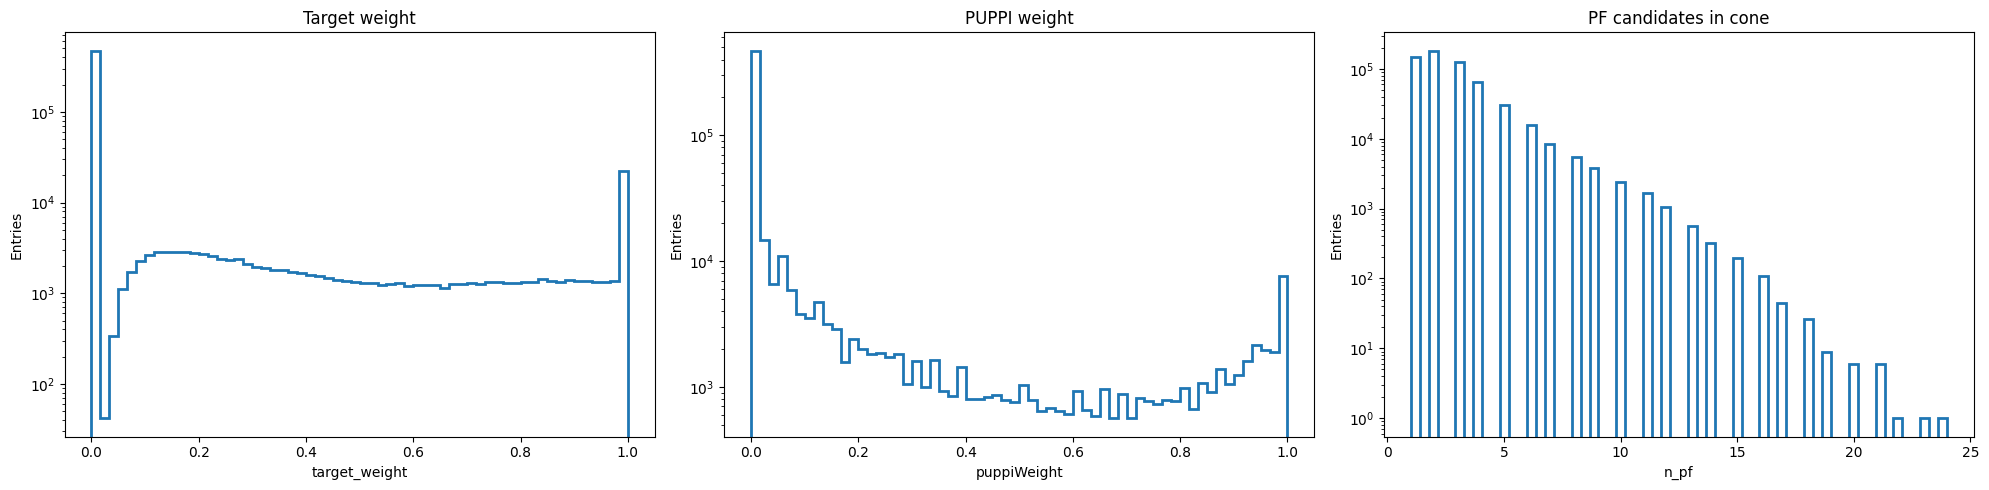

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(target_weight, bins=60, histtype="step", linewidth=2)
axes[0].set_xlabel("target_weight")
axes[0].set_ylabel("Entries")
axes[0].set_title("Target weight")

axes[1].hist(puppi_weight, bins=60, histtype="step", linewidth=2)
axes[1].set_xlabel("puppiWeight")
axes[1].set_ylabel("Entries")
axes[1].set_title("PUPPI weight")

axes[2].hist(n_pf_kept, bins=60, histtype="step", linewidth=2)
axes[2].set_xlabel("n_pf")
axes[2].set_ylabel("Entries")
axes[2].set_title("PF candidates in cone")

axes[0].set_yscale("log")
axes[1].set_yscale("log")
axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

In [10]:
def plot_pf_cloud_example(h5file, idx=0):
    with h5py.File(h5file, "r") as hf:
        x = hf["x"][idx]
        mask = hf["mask"][idx]
        target = hf["target_weight"][idx]
        matched = hf["isGenMatched"][idx]

    # extract features
    dEta = x[:, 1]
    dPhi = x[:, 2]
    logpt = x[:, 0]

    valid = mask > 0.5

    dEta = dEta[valid]
    dPhi = dPhi[valid]
    pt = np.expm1(logpt[valid])

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(
        dEta, dPhi,
        c=pt,
        s=20,
    )

    plt.colorbar(sc, label="PF pt [GeV]")

    plt.xlabel("Δη")
    plt.ylabel("Δφ")
    plt.title(
        f"PF cloud around neutral seed\n"
        #f"target={target:.3f}, matched={matched}"
    )

    plt.axhline(0)
    plt.axvline(0)

    plt.xlim(-CONFIG["cone_dr"], CONFIG["cone_dr"])
    plt.ylim(-CONFIG["cone_dr"], CONFIG["cone_dr"])

    plt.tight_layout()
    plt.show()

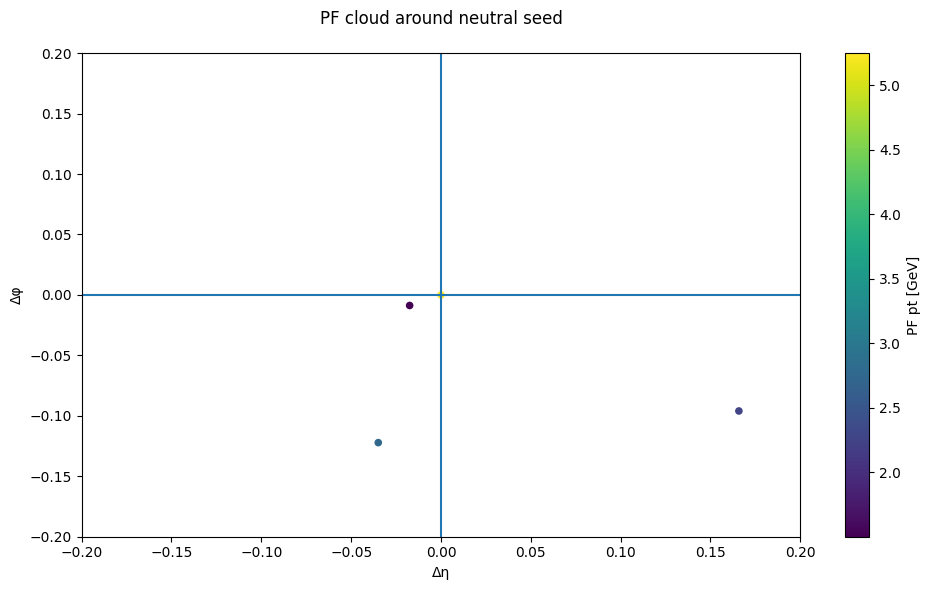

In [11]:
plot_pf_cloud_example(CONFIG["dataset_file"], idx=0)

## PyTorch dataset

In [12]:
class NeutralWeightDataset(Dataset):
    def __init__(self, h5file, indices, norm_stats=None):
        self.h5file = h5file
        self.indices = np.asarray(indices)
        self.norm_stats = norm_stats

        with h5py.File(h5file, "r") as hf:
            self.x = hf["x"][:]
            self.mask = hf["mask"][:]

            self.seed_pt = hf["seed_pt"][:]
            self.seed_eta = hf["seed_eta"][:]

            self.reco_sum = hf["recoPtSum"][:]
            self.gen_sum = hf["genPtSum"][:]

            self.target_weight = hf["target_weight"][:]
            self.puppi_weight = hf["puppiWeight"][:]

            self.is_gen_matched = hf["isGenMatched"][:]
            self.is_barrel = hf["isBarrelSeed"][:]

            self.n_pf_raw = hf["n_pf_raw"][:]
            self.n_pf_kept = hf["n_pf_kept"][:]

        self.seed_pt_log = np.log1p(np.clip(self.seed_pt, 0.0, None)).astype(np.float32)
        self.reco_sum_log = np.log1p(np.clip(self.reco_sum, 0.0, None)).astype(np.float32)

        self.feature_names = CONFIG["model_features"]
        self.feat_idx = {name: i for i, name in enumerate(self.feature_names)}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        x = self.x[idx].copy()
        mask = self.mask[idx].copy()

        seed_pt_log = self.seed_pt_log[idx]
        reco_sum_log = self.reco_sum_log[idx]

        if self.norm_stats is not None:
            valid = mask > 0.5

            for feat in ["logpt", "dEta", "dPhi", "dR"]:
                j = self.feat_idx[feat]
                mean = self.norm_stats["pf_means"][feat]
                std = self.norm_stats["pf_stds"][feat]
                x[valid, j] = (x[valid, j] - mean) / std

            seed_pt_log = (seed_pt_log - self.norm_stats["seed_mean"]) / self.norm_stats["seed_std"]
            reco_sum_log = (reco_sum_log - self.norm_stats["reco_mean"]) / self.norm_stats["reco_std"]

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),

            "seed_pt": torch.tensor([self.seed_pt[idx]], dtype=torch.float32),
            "seed_eta": torch.tensor([self.seed_eta[idx]], dtype=torch.float32),

            "seed_pt_log": torch.tensor([seed_pt_log], dtype=torch.float32),
            "reco_sum_log": torch.tensor([reco_sum_log], dtype=torch.float32),

            "recoPtSum": torch.tensor([self.reco_sum[idx]], dtype=torch.float32),
            "genPtSum": torch.tensor([self.gen_sum[idx]], dtype=torch.float32),

            "target_weight": torch.tensor([self.target_weight[idx]], dtype=torch.float32),
            "puppiWeight": torch.tensor([self.puppi_weight[idx]], dtype=torch.float32),

            "isGenMatched": torch.tensor([self.is_gen_matched[idx]], dtype=torch.int64),
            "isBarrelSeed": torch.tensor([self.is_barrel[idx]], dtype=torch.int64),

            "n_pf_raw": torch.tensor([self.n_pf_raw[idx]], dtype=torch.float32),
            "n_pf_kept": torch.tensor([self.n_pf_kept[idx]], dtype=torch.float32),
        }

## Model

In [13]:
class NeutralWeightNet(nn.Module):
    def __init__(self, in_features=6, hidden=64): #64
        super().__init__()

        self.pf_encoder = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Linear(hidden * 2 + 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def masked_pool(self, h, mask):
        mask = mask.unsqueeze(-1)
        h = h * mask
        sum_pool = h.sum(dim=1)
        mean_pool = sum_pool / mask.sum(dim=1).clamp(min=1.0)
        return sum_pool, mean_pool

    def forward(self, x, mask, seed_pt_log, reco_sum_log):
        h = self.pf_encoder(x)
        sum_pool, mean_pool = self.masked_pool(h, mask)
        extra = torch.cat([seed_pt_log, reco_sum_log], dim=1)
        z = torch.cat([sum_pool, mean_pool, extra], dim=1)
        weight = torch.sigmoid(self.head(z))
        return weight

## Splits

In [14]:
def make_splits(h5file, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    with h5py.File(h5file, "r") as hf:
        n = len(hf["target_weight"])

    idx = np.arange(n)

    train_idx, temp_idx = train_test_split(
        idx,
        test_size=(1.0 - train_frac),
        random_state=seed,
        shuffle=True
    )

    val_rel = val_frac / (val_frac + test_frac)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1.0 - val_rel),
        random_state=seed,
        shuffle=True
    )

    return train_idx, val_idx, test_idx

## Metrics: RAW vs PUPPI vs ML

In [15]:
def compute_metrics(target_w, pred_w, puppi_w, seed_pt, reco_sum, gen_sum):
    target_w = np.asarray(target_w).flatten()
    pred_w = np.asarray(pred_w).flatten()
    puppi_w = np.asarray(puppi_w).flatten()
    seed_pt = np.asarray(seed_pt).flatten()
    reco_sum = np.asarray(reco_sum).flatten()
    gen_sum = np.asarray(gen_sum).flatten()

    raw_w = np.ones_like(pred_w)

    def mae(a, b):
        return np.mean(np.abs(a - b))

    def rmse(a, b):
        return np.sqrt(np.mean((a - b) ** 2))

    raw_cone = raw_w * reco_sum
    puppi_cone = puppi_w * reco_sum
    ml_cone = pred_w * reco_sum

    return {
        "weight_rmse": float(rmse(pred_w, target_w)),
        "weight_mae": float(mae(pred_w, target_w)),

        "raw_cone_rmse": float(rmse(raw_cone, gen_sum)),
        "puppi_cone_rmse": float(rmse(puppi_cone, gen_sum)),
        "ml_cone_rmse": float(rmse(ml_cone, gen_sum)),

        "raw_cone_mae": float(mae(raw_cone, gen_sum)),
        "puppi_cone_mae": float(mae(puppi_cone, gen_sum)),
        "ml_cone_mae": float(mae(ml_cone, gen_sum)),

        "mean_target_weight": float(np.mean(target_w)),
        "mean_puppi_weight": float(np.mean(puppi_w)),
        "mean_ml_weight": float(np.mean(pred_w)),
    }

## Training and evaluation

In [16]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_weighted_loss = 0.0
    total_plain_loss = 0.0
    total_n = 0

    for batch in loader:
        x = batch["x"].to(device)
        mask = batch["mask"].to(device)
        seed_pt_log = batch["seed_pt_log"].to(device)
        reco_sum_log = batch["reco_sum_log"].to(device)
        target_weight = batch["target_weight"].to(device)

        optimizer.zero_grad()

        pred_weight = model(x, mask, seed_pt_log, reco_sum_log)

        sample_weight = 1.0 + 2.0 * target_weight.detach()

        weighted_loss = ((pred_weight - target_weight) ** 2 * sample_weight).mean()
        plain_loss = ((pred_weight - target_weight) ** 2).mean()

        weighted_loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_weighted_loss += weighted_loss.item() * bs
        total_plain_loss += plain_loss.item() * bs
        total_n += bs

    return {
        "weighted_loss": total_weighted_loss / max(total_n, 1),
        "plain_loss": total_plain_loss / max(total_n, 1),
    }
    
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    total_weighted_loss = 0.0
    total_plain_loss = 0.0
    total_n = 0

    all_target_w = []
    all_pred_w = []
    all_puppi_w = []
    all_seed_pt = []
    all_seed_eta = []
    all_reco_sum = []
    all_gen_sum = []
    all_matched = []
    all_barrel = []

    for batch in loader:
        x = batch["x"].to(device)
        mask = batch["mask"].to(device)
        seed_pt_log = batch["seed_pt_log"].to(device)
        reco_sum_log = batch["reco_sum_log"].to(device)
        target_weight = batch["target_weight"].to(device)

        pred_weight = model(x, mask, seed_pt_log, reco_sum_log)

        sample_weight = 1.0 + 2.0 * target_weight
        weighted_loss = ((pred_weight - target_weight) ** 2 * sample_weight).mean()
        plain_loss = ((pred_weight - target_weight) ** 2).mean()

        bs = x.size(0)
        total_weighted_loss += weighted_loss.item() * bs
        total_plain_loss += plain_loss.item() * bs
        total_n += bs

        all_target_w.append(target_weight.cpu().numpy())
        all_pred_w.append(pred_weight.cpu().numpy())
        all_puppi_w.append(batch["puppiWeight"].cpu().numpy())
        all_seed_pt.append(batch["seed_pt"].cpu().numpy())
        all_seed_eta.append(batch["seed_eta"].cpu().numpy())
        all_reco_sum.append(batch["recoPtSum"].cpu().numpy())
        all_gen_sum.append(batch["genPtSum"].cpu().numpy())
        all_matched.append(batch["isGenMatched"].cpu().numpy())
        all_barrel.append(batch["isBarrelSeed"].cpu().numpy())

    target_w = np.concatenate(all_target_w).flatten()
    pred_w = np.concatenate(all_pred_w).flatten()
    puppi_w = np.concatenate(all_puppi_w).flatten()
    seed_pt = np.concatenate(all_seed_pt).flatten()
    seed_eta = np.concatenate(all_seed_eta).flatten()
    reco_sum = np.concatenate(all_reco_sum).flatten()
    gen_sum = np.concatenate(all_gen_sum).flatten()
    matched = np.concatenate(all_matched).flatten()
    barrel = np.concatenate(all_barrel).flatten()

    metrics_all = compute_metrics(target_w, pred_w, puppi_w, seed_pt, reco_sum, gen_sum)

    matched_mask = matched == 1
    unmatched_mask = matched == 0

    metrics_matched = None
    metrics_unmatched = None

    if np.any(matched_mask):
        metrics_matched = compute_metrics(
            target_w[matched_mask],
            pred_w[matched_mask],
            puppi_w[matched_mask],
            seed_pt[matched_mask],
            reco_sum[matched_mask],
            gen_sum[matched_mask]
        )

    if np.any(unmatched_mask):
        metrics_unmatched = compute_metrics(
            target_w[unmatched_mask],
            pred_w[unmatched_mask],
            puppi_w[unmatched_mask],
            seed_pt[unmatched_mask],
            reco_sum[unmatched_mask],
            gen_sum[unmatched_mask]
        )

    payload = {
        "target_w": target_w,
        "pred_w": pred_w,
        "puppi_w": puppi_w,
        "seed_pt": seed_pt,
        "seed_eta": seed_eta,
        "reco_sum": reco_sum,
        "gen_sum": gen_sum,
        "matched": matched,
        "barrel": barrel,
    }

    return (
        {
            "weighted_loss": total_weighted_loss / max(total_n, 1),
            "plain_loss": total_plain_loss / max(total_n, 1),
        },
        metrics_all,
        metrics_matched,
        metrics_unmatched,
        payload,
    )

    
def run_training(config):
    set_seed(config["seed"])

    train_idx, val_idx, test_idx = make_splits(
        config["dataset_file"],
        train_frac=config["train_frac"],
        val_frac=config["val_frac"],
        test_frac=config["test_frac"],
        seed=config["seed"]
    )

    patience = config.get("early_stopping_patience", None)
    min_delta = config.get("early_stopping_min_delta", 0.0)
    epochs_without_improvement = 0

    # ------------------------------------------------------------
    # Compute normalization stats from TRAIN split only
    # ------------------------------------------------------------
    with h5py.File(config["dataset_file"], "r") as hf:
        x_all = hf["x"][:]
        mask_all = hf["mask"][:]
        seed_pt_all = hf["seed_pt"][:]
        reco_sum_all = hf["recoPtSum"][:]

    feat_idx = {name: i for i, name in enumerate(config["model_features"])}

    std_features = ["logpt", "dEta", "dPhi", "dR"]
    pf_means = {}
    pf_stds = {}

    train_mask = mask_all[train_idx] > 0

    for feat in std_features:
        idx = feat_idx[feat]
        vals = x_all[train_idx, :, idx][train_mask]
        pf_means[feat] = float(vals.mean())
        pf_stds[feat] = float(vals.std() + 1e-6)

    seed_pt_log_all = np.log1p(np.clip(seed_pt_all, 0.0, None))
    reco_sum_log_all = np.log1p(np.clip(reco_sum_all, 0.0, None))

    seed_mean = float(seed_pt_log_all[train_idx].mean())
    seed_std = float(seed_pt_log_all[train_idx].std() + 1e-6)

    reco_mean = float(reco_sum_log_all[train_idx].mean())
    reco_std = float(reco_sum_log_all[train_idx].std() + 1e-6)

    norm_stats = {
        "pf_means": pf_means,
        "pf_stds": pf_stds,
        "seed_mean": seed_mean,
        "seed_std": seed_std,
        "reco_mean": reco_mean,
        "reco_std": reco_std,
    }

    # Optional: save them
    with open(os.path.join(config["output_dir"], "normalisation.json"), "w") as f:
        json.dump(norm_stats, f, indent=2)

    # ------------------------------------------------------------
    # Create datasets with normalization applied
    # ------------------------------------------------------------
    train_ds = NeutralWeightDataset(config["dataset_file"], train_idx, norm_stats=norm_stats)
    val_ds = NeutralWeightDataset(config["dataset_file"], val_idx, norm_stats=norm_stats)
    test_ds = NeutralWeightDataset(config["dataset_file"], test_idx, norm_stats=norm_stats)

    train_loader = DataLoader(
        train_ds, batch_size=config["batch_size"], shuffle=True, num_workers=config["num_workers"]
    )
    val_loader = DataLoader(
        val_ds, batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"]
    )
    test_loader = DataLoader(
        test_ds, batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"]
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    model = NeutralWeightNet(
        in_features=len(config["model_features"]),
        hidden=64
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    
    # ------------------------------------------------------------
    # Resume from checkpoint if it exists
    # ------------------------------------------------------------
    ckpt_path = os.path.join(config["output_dir"], "last_checkpoint.pt")

    start_epoch = 0
    best_val_loss = float("inf")

    history = {
       "train_weighted_loss": [],
        "train_plain_loss": [],
        "val_weighted_loss": [],
        "val_plain_loss": [],
    }

    if os.path.exists(ckpt_path):
        print(f"🔁 Found checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)

        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

        history = ckpt["history"]
        start_epoch = ckpt["epoch"]
        best_val_loss = ckpt.get("best_val_loss", float("inf"))

        print(f"Resuming from epoch {start_epoch}")
    else:
        print("🆕 No checkpoint found, starting from scratch")
    
    
    for epoch in range(start_epoch, config["epochs"]):
    #for epoch in range(config["epochs"]):

        # --- Training ---
        train_losses = train_one_epoch(model, train_loader, optimizer, device)

        # --- Validation ---
        val_losses, val_all, val_matched, val_unmatched, _ = evaluate(model, val_loader, device)

        history["train_weighted_loss"].append(train_losses["weighted_loss"])
        history["train_plain_loss"].append(train_losses["plain_loss"])
        history["val_weighted_loss"].append(val_losses["weighted_loss"])
        history["val_plain_loss"].append(val_losses["plain_loss"])

        print(f"\nEpoch {epoch+1:02d}/{config['epochs']}")
        print(f"  train weighted loss: {train_losses['weighted_loss']:.6f}")
        print(f"  train plain MSE    : {train_losses['plain_loss']:.6f}")
        print(f"  val weighted loss  : {val_losses['weighted_loss']:.6f}")
        print(f"  val plain MSE      : {val_losses['plain_loss']:.6f}")
        print(f"  val weight_rmse    : {val_all['weight_rmse']:.6f}")
        print(f"  val raw   cone_rmse: {val_all['raw_cone_rmse']:.6f}")
        print(f"  val puppi cone_rmse: {val_all['puppi_cone_rmse']:.6f}")
        print(f"  val ML    cone_rmse: {val_all['ml_cone_rmse']:.6f}")

        # ------------------------------------------------------------
        # Save last checkpoint (for resume/debug)
        # ------------------------------------------------------------
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "best_val_loss": best_val_loss,
            },
            os.path.join(config["output_dir"], "last_checkpoint.pt")
        )

        if val_matched is not None:
            print(f"  matched   raw/puppi/ML cone_rmse: "
                  f"{val_matched['raw_cone_rmse']:.6f} / "
                  f"{val_matched['puppi_cone_rmse']:.6f} / "
                  f"{val_matched['ml_cone_rmse']:.6f}")

        if val_unmatched is not None:
            print(f"  unmatched raw/puppi/ML cone_rmse: "
                  f"{val_unmatched['raw_cone_rmse']:.6f} / "
                  f"{val_unmatched['puppi_cone_rmse']:.6f} / "
                  f"{val_unmatched['ml_cone_rmse']:.6f}")

        if val_losses["plain_loss"] < (best_val_loss - min_delta):
            best_val_loss = val_losses["plain_loss"]
            epochs_without_improvement = 0
            torch.save(model.state_dict(), config["model_file"])
            print(f"  saved best model -> {config['model_file']}")
        else:
            epochs_without_improvement += 1
            print(f"  no significant improvement for {epochs_without_improvement} epoch(s)")
            
        #if val_losses["plain_loss"] < best_val_loss:
        #    best_val_loss = val_losses["plain_loss"]
        #    torch.save(model.state_dict(), config["model_file"])
        #    print(f"  saved best model -> {config['model_file']}")

        if patience is not None and epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs.")
            print(f"No validation improvement larger than {min_delta} for {patience} consecutive epochs.")
            break

        # ------------------------------------------------------------
        # Save history every epoch
        # ------------------------------------------------------------
        with open(os.path.join(config["output_dir"], "history.json"), "w") as f:
            json.dump(history, f, indent=2)


    model.load_state_dict(torch.load(config["model_file"], map_location=device))

    test_losses, test_all, test_matched, test_unmatched, test_payload = evaluate(model, test_loader, device)

    print("\n================ Final Test Results ================")
    print(f"test weighted loss      : {test_losses['weighted_loss']:.6f}")
    print(f"test plain MSE          : {test_losses['plain_loss']:.6f}")
    print(f"test weight_rmse        : {test_all['weight_rmse']:.6f}")
    print(f"test raw   cone_rmse    : {test_all['raw_cone_rmse']:.6f}")
    print(f"test puppi cone_rmse    : {test_all['puppi_cone_rmse']:.6f}")
    print(f"test ML    cone_rmse    : {test_all['ml_cone_rmse']:.6f}")
    print(f"test raw   cone_mae     : {test_all['raw_cone_mae']:.6f}")
    print(f"test puppi cone_mae     : {test_all['puppi_cone_mae']:.6f}")
    print(f"test ML    cone_mae     : {test_all['ml_cone_mae']:.6f}")

    if test_matched is not None:
        print("\nMatched only:")
        print(f"  raw   cone_rmse: {test_matched['raw_cone_rmse']:.6f}")
        print(f"  puppi cone_rmse: {test_matched['puppi_cone_rmse']:.6f}")
        print(f"  ML    cone_rmse: {test_matched['ml_cone_rmse']:.6f}")

    if test_unmatched is not None:
        print("\nUnmatched only:")
        print(f"  raw   cone_rmse: {test_unmatched['raw_cone_rmse']:.6f}")
        print(f"  puppi cone_rmse: {test_unmatched['puppi_cone_rmse']:.6f}")
        print(f"  ML    cone_rmse: {test_unmatched['ml_cone_rmse']:.6f}")

    return model, history, test_payload

## Train model

In [17]:
model, history, test_payload = run_training(CONFIG)

Using device: cpu
🆕 No checkpoint found, starting from scratch

Epoch 01/20
  train weighted loss: 0.084976
  train plain MSE    : 0.046563
  val weighted loss  : 0.076589
  val plain MSE      : 0.038835
  val weight_rmse    : 0.197067
  val raw   cone_rmse: 11.369505
  val puppi cone_rmse: 6.299102
  val ML    cone_rmse: 5.672500
  matched   raw/puppi/ML cone_rmse: 13.525557 / 14.673489 / 12.354390
  unmatched raw/puppi/ML cone_rmse: 10.995376 / 3.507060 / 3.660578
  saved best model -> PUPPILML_NeutralWeight_Barrel/best_model.pt

Epoch 02/20
  train weighted loss: 0.075054
  train plain MSE    : 0.040153
  val weighted loss  : 0.074313
  val plain MSE      : 0.037650
  val weight_rmse    : 0.194035
  val raw   cone_rmse: 11.369505
  val puppi cone_rmse: 6.299102
  val ML    cone_rmse: 5.564301
  matched   raw/puppi/ML cone_rmse: 13.525557 / 14.673489 / 12.043481
  unmatched raw/puppi/ML cone_rmse: 10.995376 / 3.507060 / 3.630012
  saved best model -> PUPPILML_NeutralWeight_Barrel/bes

In [ ]:
#import json
#import matplotlib.pyplot as plt

#history_file = "PUPPILML_NeutralWeight_Barrel/history.json"

#with open(history_file, "r") as f:
#    history = json.load(f)

#print("Available keys:", history.keys())

## Plotting helpers

In [26]:
plt.style.use(hep.style.CMS)

def cms_label(ax, data=False, year=None, com=14, lumi=None, text="Preliminary"):
    """
    Wrapper around mplhep CMS label.
    """
    hep.cms.label(
        data=data,
        year=year,
        com=com,
        lumi=lumi,
        label=text,
        ax=ax
    )


def add_region_text(ax, barrel_eta_max=1.5, extra_lines=None):
    #lines = [rf"Phase-2, neutral seeds, barrel only: $|\eta^{{\mathrm{{calo}}}}_{{\mathrm{{seed}}}}| < {barrel_eta_max}$"]
    lines = [rf"Phase-2, neutral seeds, barrel only: $|\eta_{{\mathrm{{seed}}}}| < {barrel_eta_max}$"]
    if extra_lines is not None:
        lines.extend(extra_lines)

    ax.text(
        0.45, 0.95, #0.03, 0.92,
        "\n".join(lines),
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=13
    )

def plot_history(history, config, savepath=None):
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(history["train_weighted_loss"], label="Training weighted loss")
    ax.plot(history["val_weighted_loss"], label="Validation weighted loss")
    ax.plot(history["train_plain_loss"], "--", label="Training plain MSE")
    ax.plot(history["val_plain_loss"], "--", label="Validation plain MSE")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    #ax.set_title("Training history for neutral-weight regression")
    #ax.set_yscale("log")
    
    cms_label(ax)
    add_region_text(ax, barrel_eta_max=config["barrel_eta_max"])

    ax.legend()
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=150)
        plt.close(fig)
    else:
        plt.show()

def plot_weight_distribution(payload, config, savepath=None):
    target_w = payload["target_w"]
    pred_w = payload["pred_w"]
    puppi_w = payload["puppi_w"]

    fig, ax = plt.subplots(figsize=(9, 6))
    bins = np.linspace(0.0, 1.0, 80)

    ax.hist(target_w, bins=bins, histtype="step", density=True, linewidth=2, label="Target weight")
    ax.hist(puppi_w, bins=bins, histtype="step", density=True, linewidth=2, label="PUPPI weight")
    ax.hist(pred_w, bins=bins, histtype="step", density=True, linewidth=2, label="ML predicted weight")

    ax.set_xlabel("Neutral weight")
    ax.set_ylabel("Density")
    ax.set_yscale("log")
    ax.set_ylim(0.0001)
    #ax.set_title("Neutral-weight distributions: target vs PUPPI vs ML")

    cms_label(ax)
    add_region_text(
        ax,
        barrel_eta_max=config["barrel_eta_max"],
        extra_lines=[
            f"N = {len(target_w):,}",
            f"Mean target = {np.mean(target_w):.3f}",
            f"Mean PUPPI = {np.mean(puppi_w):.3f}",
            f"Mean ML = {np.mean(pred_w):.3f}",
        ]
    )

    ax.legend(loc=3)
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=150)
        plt.close(fig)
    else:
        plt.show()


def plot_weight_matched_unmatched(payload, config, savepath=None):
    matched = payload["matched"]
    pred_w = payload["pred_w"]
    puppi_w = payload["puppi_w"]
    target_w = payload["target_w"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)
    bins = np.linspace(0.0, 1.0, 80)

    masks = {
        "Matched neutral seeds": matched == 1,
        "Unmatched neutral seeds": matched == 0,
    }

    for ax, (title, mask) in zip(axes, masks.items()):
        n_sel = np.sum(mask)
        if n_sel == 0:
            continue

        ax.hist(target_w[mask], bins=bins, histtype="step", density=True, linewidth=2, label="Target")
        ax.hist(puppi_w[mask], bins=bins, histtype="step", density=True, linewidth=2, label="PUPPI")
        ax.hist(pred_w[mask], bins=bins, histtype="step", density=True, linewidth=2, label="ML")

        ax.set_xlabel("Neutral weight")
        ax.set_yscale("log")

        cms_label(ax)
        add_region_text(
            ax,
            barrel_eta_max=config["barrel_eta_max"],
            extra_lines=[f"N = {n_sel:,}"]
        )

        # Add matched / unmatched label inside each panel
        ax.text(
            0.5, 0.85,
            title,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=16,
            fontweight="bold"
        )

        # Optional: add mean values for quick reading
        ax.text(
            0.5, 0.78,
            "\n".join([
                f"Mean target = {np.mean(target_w[mask]):.3f}",
                f"Mean PUPPI = {np.mean(puppi_w[mask]):.3f}",
                f"Mean ML = {np.mean(pred_w[mask]):.3f}",
            ]),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=15
        )

    axes[0].set_ylabel("Density")
    axes[1].legend()
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

def plot_pred_vs_target(payload, config, savepath=None):
    target_w = payload["target_w"]
    pred_w = payload["pred_w"]
    rmse = np.sqrt(np.mean((pred_w - target_w) ** 2))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(target_w, pred_w, s=3, alpha=0.20)
    ax.plot([0, 1], [0, 1], "--", linewidth=1.5)

    ax.set_xlabel("Target neutral weight")
    ax.set_ylabel("ML predicted neutral weight")
    #ax.set_title("Predicted vs target neutral weight")

    cms_label(ax)
    add_region_text(
        ax,
        barrel_eta_max=config["barrel_eta_max"],
        extra_lines=[
            f"N = {len(target_w):,}",
            f"Weight RMSE = {rmse:.3f}",
        ]
    )

    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=150)
        plt.close(fig)
    else:
        plt.show()


def plot_cone_residuals(payload, config, savepath=None):
    pred_w = payload["pred_w"]
    puppi_w = payload["puppi_w"]
    reco_sum = payload["reco_sum"]
    gen_sum = payload["gen_sum"]

    raw_res = reco_sum - gen_sum
    puppi_res = puppi_w * reco_sum - gen_sum
    ml_res = pred_w * reco_sum - gen_sum

    def rmse(x):
        return np.sqrt(np.mean(x**2))

    def mae(x):
        return np.mean(np.abs(x))

    #lo = min(np.percentile(raw_res, 0.5), np.percentile(puppi_res, 0.5), np.percentile(ml_res, 0.5))
    #hi = max(np.percentile(raw_res, 99.5), np.percentile(puppi_res, 99.5), np.percentile(ml_res, 99.5))
    #bins = np.linspace(lo, hi, 120)
    #fig, ax = plt.subplots(figsize=(9, 6))
    #ax.hist(raw_res, bins=bins, histtype="step", density=True, linewidth=2, label="Raw reco cone - gen cone")
    #ax.hist(puppi_res, bins=bins, histtype="step", density=True, linewidth=2, label="PUPPI-corrected cone - gen cone")
    #ax.hist(ml_res, bins=bins, histtype="step", density=True, linewidth=2, label="ML-corrected cone - gen cone")

    xmin, xmax = -20, 60
    bins = np.linspace(xmin, xmax, 120)

    fig, ax = plt.subplots(figsize=(10, 9))

    ax.hist(raw_res, bins=bins, histtype="step", density=True, linewidth=2,
            label="Raw reco cone - gen cone")
    ax.hist(puppi_res, bins=bins, histtype="step", density=True, linewidth=2,
            label="PUPPI-corrected cone - gen cone")
    ax.hist(ml_res, bins=bins, histtype="step", density=True, linewidth=2,
            label="ML-corrected cone - gen cone")

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Cone residual [GeV]")
    ax.set_ylabel("Density")
    #ax.set_ylim(0, 1.5)
    #ax.set_title("Cone residual comparison: Raw vs PUPPI vs ML")

    cms_label(ax)
    add_region_text(
        ax,
        barrel_eta_max=config["barrel_eta_max"],
        extra_lines=[
            f"N = {len(pred_w):,}",
            f"Raw RMSE = {rmse(raw_res):.2f} GeV",
            f"PUPPI RMSE = {rmse(puppi_res):.2f} GeV",
            f"ML RMSE = {rmse(ml_res):.2f} GeV",
            f"Raw MAE = {mae(raw_res):.2f} GeV",
            f"PUPPI MAE = {mae(puppi_res):.2f} GeV",
            f"ML MAE = {mae(ml_res):.2f} GeV",
        ]
    )

    ax.legend(loc=5, fontsize=18)
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=150)
        plt.close(fig)
    else:
        plt.show()


def plot_seed_pt_proxy(payload, config, savepath=None):
    pred_w = payload["pred_w"]
    puppi_w = payload["puppi_w"]
    seed_pt = payload["seed_pt"]

    raw_seed = seed_pt
    puppi_seed = puppi_w * seed_pt
    ml_seed = pred_w * seed_pt

    xmax = np.percentile(raw_seed, 99.5)
    bins = np.linspace(0, xmax, 100)

    fig, ax = plt.subplots(figsize=(10, 9))
    ax.hist(raw_seed, bins=bins, histtype="step", density=True, linewidth=2, label="Raw neutral seed $p_T$")
    ax.hist(puppi_seed, bins=bins, histtype="step", density=True, linewidth=2, label="PUPPI-weighted neutral seed $p_T$")
    ax.hist(ml_seed, bins=bins, histtype="step", density=True, linewidth=2, label="ML-weighted neutral seed $p_T$")

    ax.set_xlabel(r"Neutral seed $p_T$ [GeV]")
    ax.set_ylabel("Density")
    ax.set_yscale("log")
    ax.set_ylim(0.0001, 30)
    #ax.set_title("Neutral seed $p_T$ before and after weighting (proxy only)")

    cms_label(ax)
    #add_region_text(
    #    ax,
    #    barrel_eta_max=config["barrel_eta_max"],
        #extra_lines=[
        #    "This is a qualitative proxy only.",
        #    "It does not use matched seed-gen $p_T$.",
        #]
    #)

    ax.legend(loc=1, fontsize=18)
    fig.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=150)
        plt.close(fig)
    else:
        plt.show()

## Quick validation

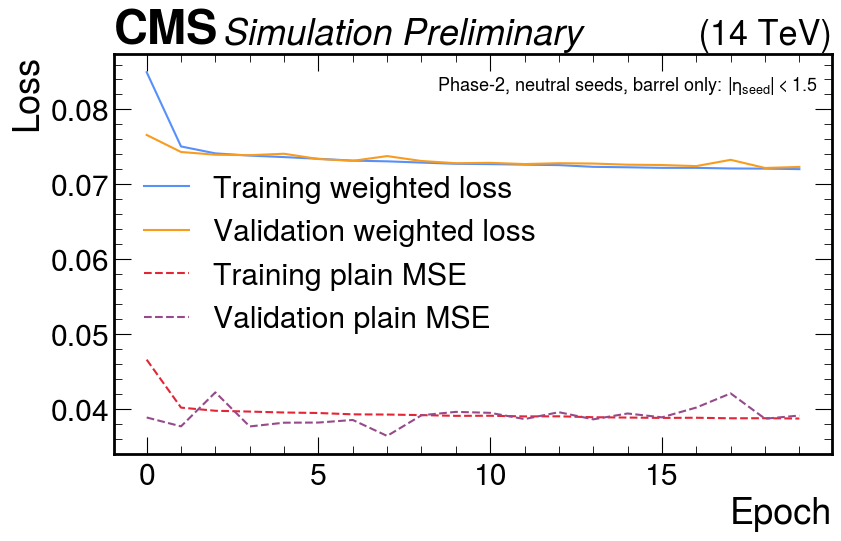

In [27]:
plot_history(history, CONFIG)

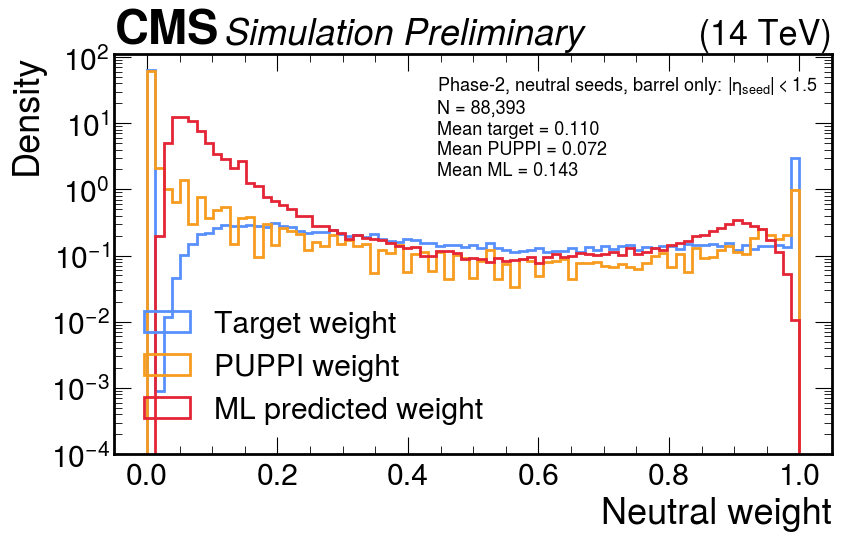

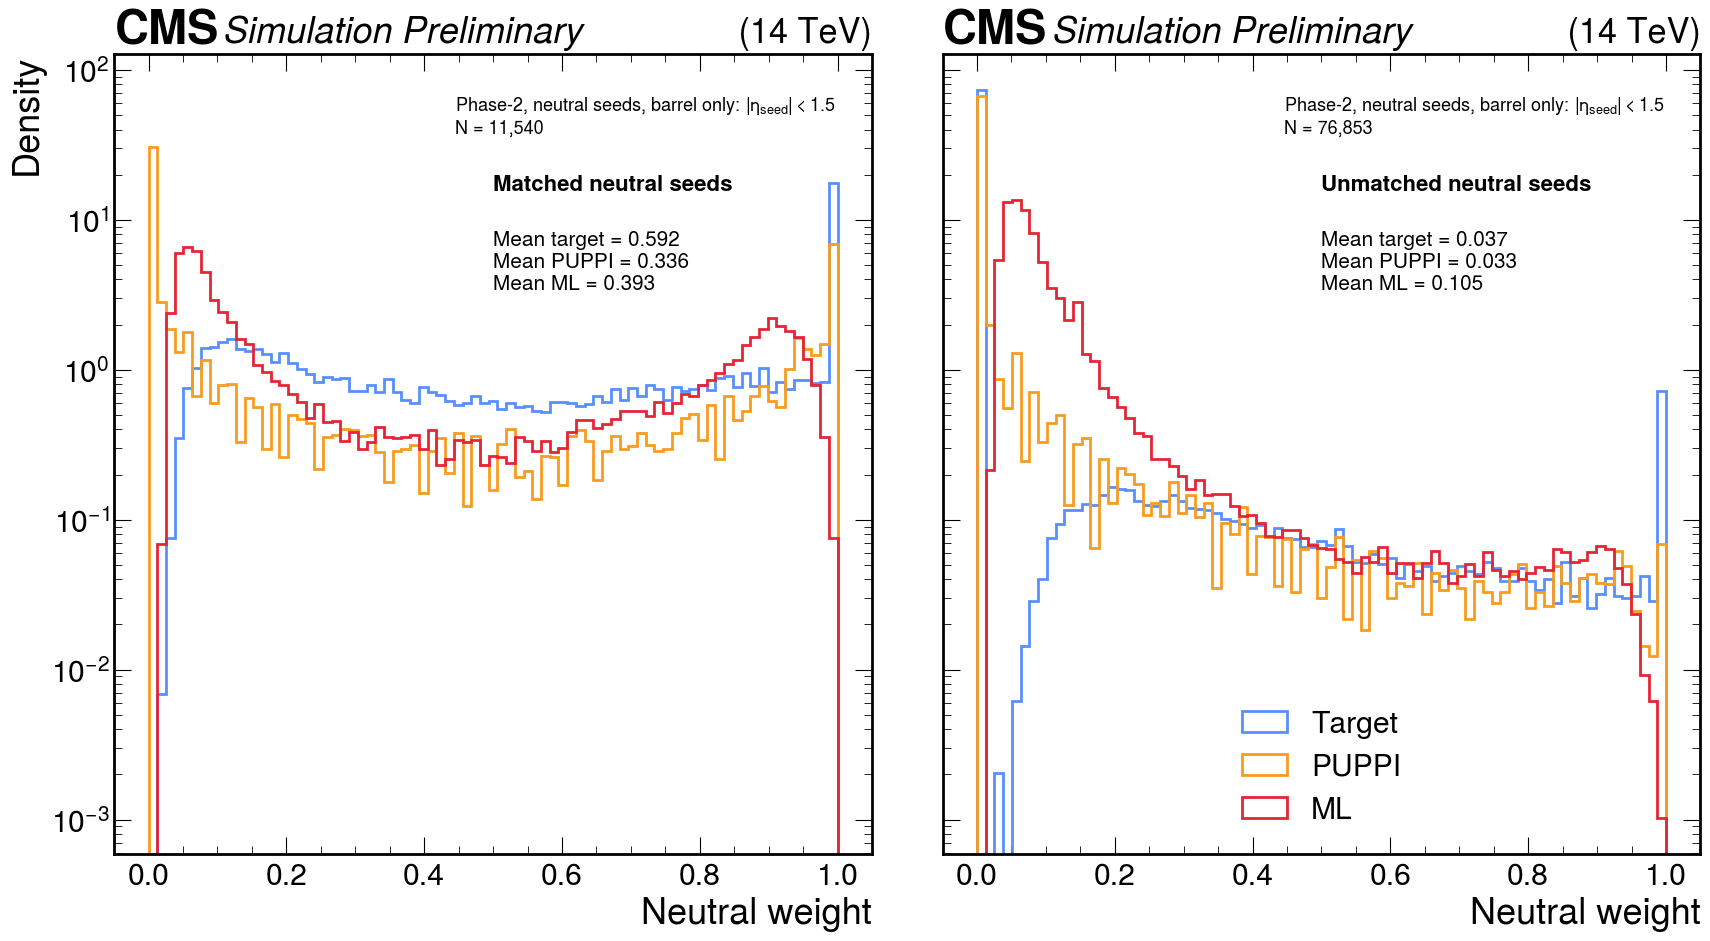

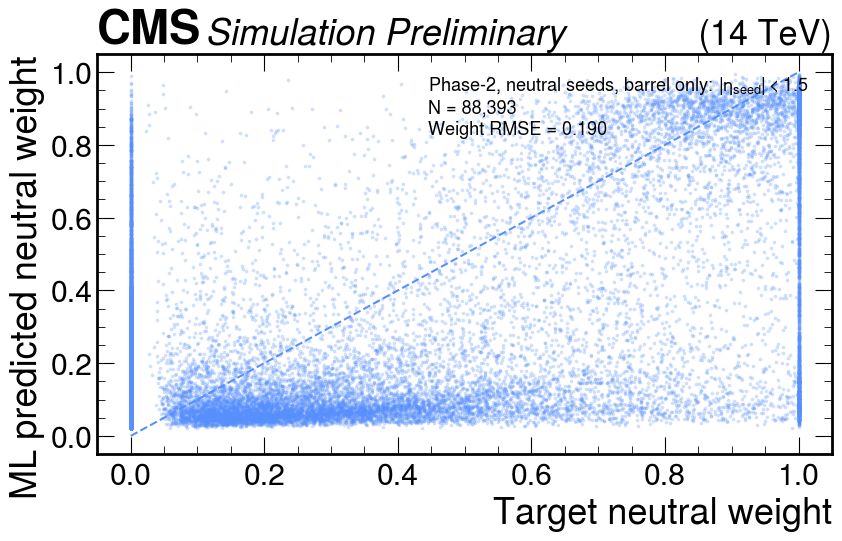

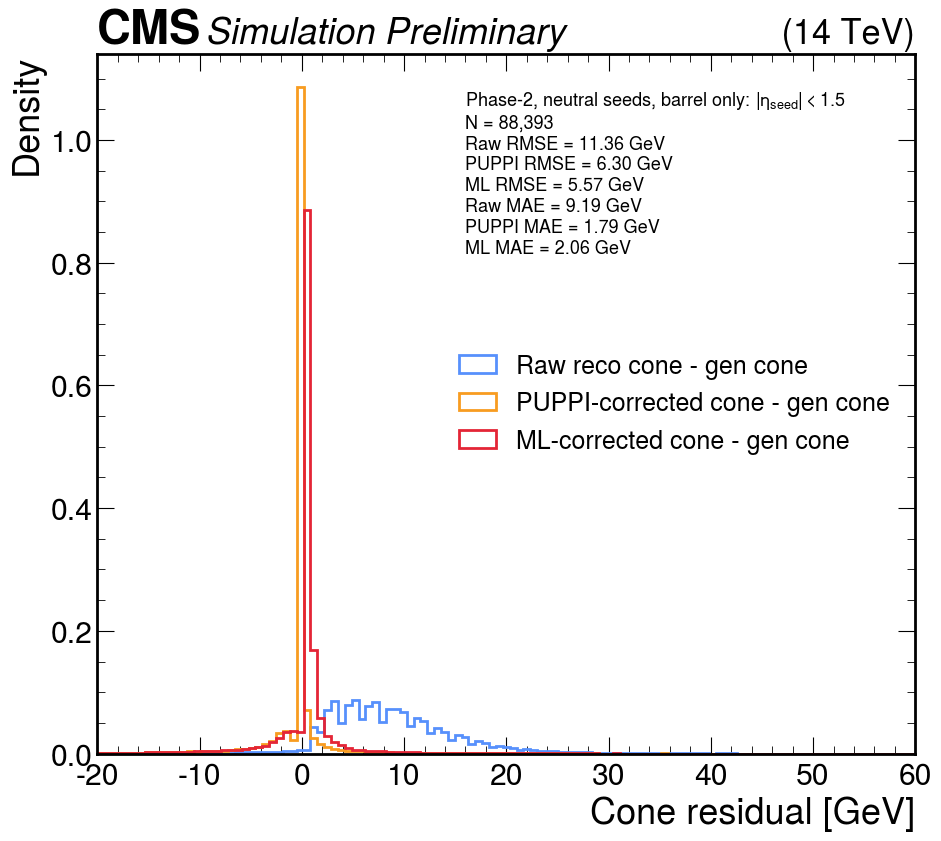

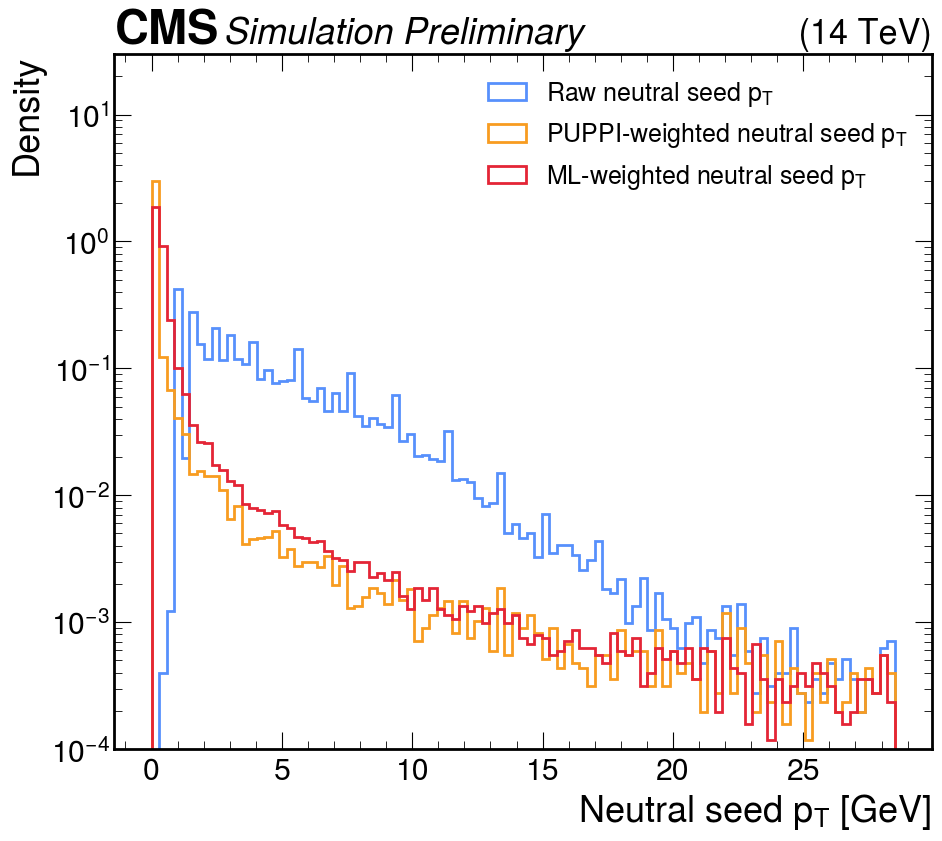

In [20]:
plot_weight_distribution(test_payload, CONFIG)
plot_weight_matched_unmatched(test_payload, CONFIG)
plot_pred_vs_target(test_payload, CONFIG)
plot_cone_residuals(test_payload, CONFIG)
plot_seed_pt_proxy(test_payload, CONFIG)

In [21]:
plot_history(history, CONFIG, savepath=os.path.join(CONFIG["output_dir"], "loss_history.png"))
plot_weight_distribution(test_payload, CONFIG, savepath=os.path.join(CONFIG["output_dir"], "weight_distribution_target_puppi_ml.png"))
plot_weight_matched_unmatched(test_payload, CONFIG, savepath=os.path.join(CONFIG["output_dir"], "weight_distribution_matched_unmatched.png"))
plot_pred_vs_target(test_payload, CONFIG, savepath=os.path.join(CONFIG["output_dir"], "pred_vs_target_weight.png"))
plot_cone_residuals(test_payload, CONFIG, savepath=os.path.join(CONFIG["output_dir"], "cone_residuals_raw_puppi_ml.png"))
plot_seed_pt_proxy(test_payload, CONFIG, savepath=os.path.join(CONFIG["output_dir"], "seed_pt_proxy_raw_puppi_ml.png"))

print("Saved plots to:", CONFIG["output_dir"])

Saved plots to: PUPPILML_NeutralWeight_Barrel/
